# 探索性数据分析 EDA 与数据清理（pandas 实战）

> 📌 **出处**：李沐《实用机器学习》「探索性数据分析、数据清理、数据变换」
> 🎯 **目标**：拿到数据后**先别急着建模**——先做 **EDA**（摸清数据的脾气）和**数据清理**（处理缺失、异常、重复），把「脏数据」洗成「能用的数据」。

## 为什么先看数据

数据里的坑（缺失值、异常值、类型错误）不清理，模型学到的是噪声。**EDA = 用统计 + 可视化「诊断」数据；清理 = 对症「治疗」。**


In [1]:
# ==================== 环境准备 ====================
import torch
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'PingFang SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

蓝 = '#2b7bba'; 橙 = '#e69f00'; 灰 = '#999999'; 红 = '#d62728'; 绿 = '#2ca02c'; 紫 = '#9467bd'
np.random.seed(0); torch.manual_seed(0)

print("✓ 环境就绪：torch", torch.__version__)


✓ 环境就绪：torch 2.14.0+cpu


## 1. 造一份「有毛病」的数据

故意埋进四类常见坑：**缺失值、异常值、重复行、错误类型**，后面一个个清理。


In [2]:
# ---- 造一份「脏数据」 ----
import pandas as pd
import numpy as np

np.random.seed(0)
n = 300
df = pd.DataFrame({
    'age': np.random.normal(35, 8, n).round(),
    'income': np.random.normal(20, 6, n).round(1),
    'city': np.random.choice(['北京', '上海', '广州', None], n, p=[0.3, 0.3, 0.3, 0.1]),  # 有缺失
    'y': np.random.choice([0, 1], n),
})
# 埋坑①：异常值（年龄 999）
df.loc[0, 'age'] = 999
# 埋坑②：重复行
df = pd.concat([df, df.iloc[:5]])   # 前 5 行重复
# 埋坑③：错误类型——整列 age 被读成字符串（模拟 CSV 没指定 dtype），还混进一个非数字
df['age'] = df['age'].astype(str)
df.loc[1, 'age'] = 'abc'
df.index = range(len(df))

print("脏数据 shape：", df.shape)
print(df.head(8))
print("\n各列缺失值：\n", df.isna().sum())
print("\nage 列类型：", df['age'].dtype, "（应该是 object，即「错误类型」）")


脏数据 shape： (305, 4)
     age  income  city  y
0  999.0    12.2    上海  0
1    abc    29.9    北京  0
2   43.0    19.3    上海  1
3   53.0    15.9    北京  0
4   50.0    24.0  None  1
5   27.0    17.2  None  1
6   43.0    12.0    上海  1
7   34.0    11.9    北京  0

各列缺失值：
 age        0
income     0
city      32
y          0
dtype: int64

age 列类型： object （应该是 object，即「错误类型」）


## 2. EDA：先「摸清脾气」

- **分布**：数值特征画直方图，看有没有异常；
- **相关性**：数值特征两两的皮尔逊相关系数；
- **类别分布**：类别特征各取值多少。


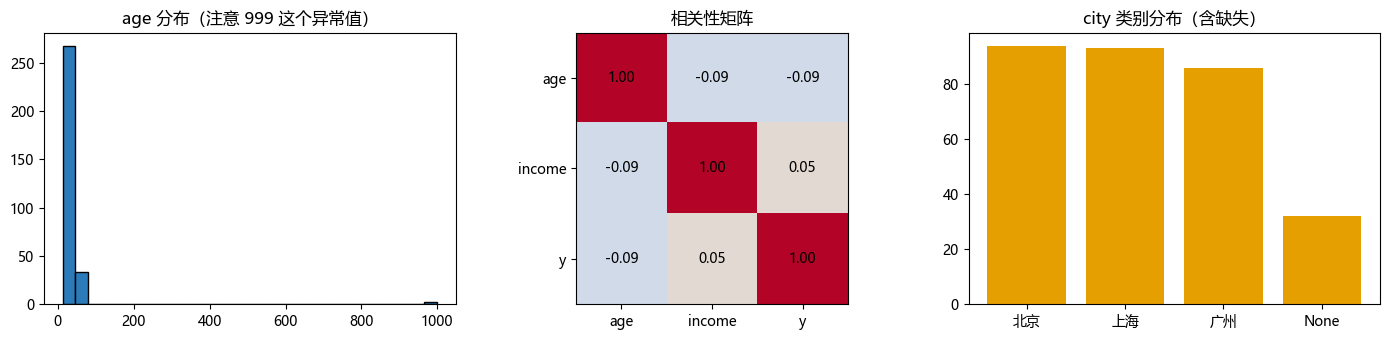

In [3]:
# ---- EDA：分布 + 相关性 + 类别分布 ----
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

# ① 数值分布（能看到 age 的 999 异常值）
axes[0].hist(pd.to_numeric(df['age'], errors='coerce').dropna(), bins=30, color=蓝, edgecolor='k')
axes[0].set_title('age 分布（注意 999 这个异常值）')

# ② 相关性热力图
num = df[['age', 'income', 'y']].apply(pd.to_numeric, errors='coerce')
corr = num.corr()
im = axes[1].imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(corr.columns)
axes[1].set_yticks(range(3)); axes[1].set_yticklabels(corr.columns)
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
axes[1].set_title('相关性矩阵')

# ③ 类别分布
vc = df['city'].value_counts(dropna=False)
axes[2].bar([str(k) for k in vc.index], vc.values, color=橙)
axes[2].set_title('city 类别分布（含缺失）')

plt.tight_layout()
plt.show()


## 3. 数据清理：对症下药

| 问题 | 处理 |
| --- | --- |
| 缺失值 | 删除 / 填充（均值、中位数、众数、前向填充） |
| 异常值 | 用分位数截断 / 按业务规则过滤 |
| 重复行 | `drop_duplicates` |
| 类型错误 | `pd.to_numeric` / `astype` 强制转换 |


清理后 shape： (299, 4) （去掉了 6 个重复行）
缺失值：
 age       0
income    0
city      0
y         0
dtype: int64
age 最大值（清理后应<999）： 53.0


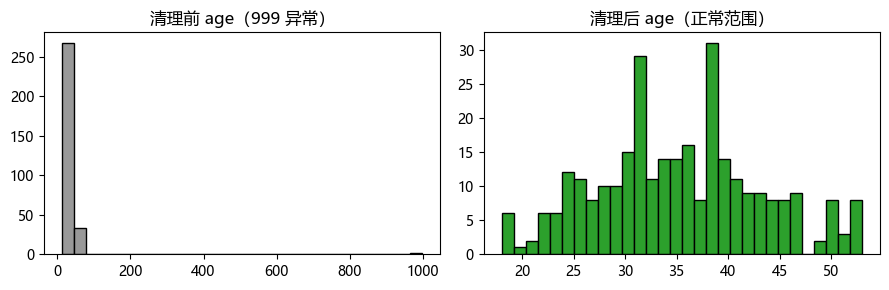

In [4]:
# ---- 清理四连 ----
clean = df.copy()

# ① 类型：把 age 强制转数值（非数字变 NaN）
clean['age'] = pd.to_numeric(clean['age'], errors='coerce')

# ② 异常值：用 1%/99% 分位数截断（age 999 被压下来）
lo, hi = clean['age'].quantile([0.01, 0.99])
clean['age'] = clean['age'].clip(lo, hi)

# ③ 缺失值：数值用中位数填充，类别用众数填充
clean['age'] = clean['age'].fillna(clean['age'].median())
clean['city'] = clean['city'].fillna(clean['city'].mode()[0])

# ④ 重复行：删除
clean = clean.drop_duplicates().reset_index(drop=True)

print("清理后 shape：", clean.shape, "（去掉了", df.shape[0] - clean.shape[0], "个重复行）")
print("缺失值：\n", clean.isna().sum())
print("age 最大值（清理后应<999）：", clean['age'].max())

# 清理前后对比
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].hist(pd.to_numeric(df['age'], errors='coerce').dropna(), bins=30, color=灰, edgecolor='k')
axes[0].set_title('清理前 age（999 异常）')
axes[1].hist(clean['age'], bins=30, color=绿, edgecolor='k')
axes[1].set_title('清理后 age（正常范围）')
plt.tight_layout()
plt.show()


## 小结

| 步骤 | 做什么 |
| --- | --- |
| EDA | 看分布、相关性、缺失、类别占比，摸清数据 |
| 缺失值 | 删 / 填（均值/中位数/众数） |
| 异常值 | 分位数截断 / 业务规则过滤 |
| 重复行 | drop_duplicates |
| 类型错误 | to_numeric / astype 强制转换 |

> 🔑 **记忆**：**先 EDA 后建模**。真实数据几乎都有坑，不清理就建模等于「在垃圾上盖楼」。EDA 的分布/相关性/缺失「三板斧」是每个数据科学家的基本功。
